<a href="https://colab.research.google.com/github/subhashiitb/100-Days-of-ML/blob/main/ML%20Project/Breast%20Cancer/BC-detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Breast Cancer Detection Code - Logistic Regression Example

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/breast-cancer-wisconsin-data")

print("Path to dataset files:", path)

In [5]:
import numpy as np
import pandas as pd
import sklearn.datasets
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [6]:
df = pd.read_csv(path + "/data.csv")
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [ ]:
# Adding the target columns to the dataset

In [7]:
df['label'] = df['diagnosis'].map({'M': 1, 'B': 0})
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32,label
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN,1
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN,1
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN,1
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN,1
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN,1


In [8]:
# Remove the column name nn nmaed 32

In [10]:
df.drop(columns=['Unnamed: 32'], inplace=True)
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,label
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


In [11]:
df.shape

(569, 33)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [13]:
df.drop(columns=['id'], inplace=True)
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,label
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


In [14]:
df.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,label
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.372583
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,0.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [15]:
df.duplicated().sum( )

np.int64(0)

In [16]:
missing_values = df.isna().sum()
#print(missing_values)
#print(missing_values.items()) # Calculate and print the number of missing values in each column of the DataFrame
print("df:", len(df))

df: 569


In [17]:
if missing_values.sum() == 0:
    print("There are no missing values.")
else:
    for col, count in missing_values.items():
        print(f'{col}: {count} missing values')
        if count > 0:
            percentage_missing = (count / len(df)) * 100
            print(f'{col}: {percentage_missing:.1f}%')

There are no missing values.


In [18]:
class_count = df['diagnosis'].value_counts()
print(class_count)

diagnosis
B    357
M    212
Name: count, dtype: int64


In [23]:
percentage = df['diagnosis'].value_counts(normalize=True)*100 # Calculate the percentage of each class in the 'diagnosis' column
print(percentage)

diagnosis
B    62.741652
M    37.258348
Name: proportion, dtype: float64


In [24]:
print(f'Malignant Tumors: {class_count["M"]} ({percentage["M"]:.2f}%)')
print(f'Benign Tumors: {class_count["B"]} ({percentage["B"]:.2f}%)')

Malignant Tumors: 212 (37.26%)
Benign Tumors: 357 (62.74%)


In [25]:
numeric_cols = df.select_dtypes(include = 'number').columns # Select columns with numeric data types
print("Total number of numerical columns present :",     len(numeric_cols))


Total number of numerical columns present : 31


In [ ]:
## Univariate Analysis

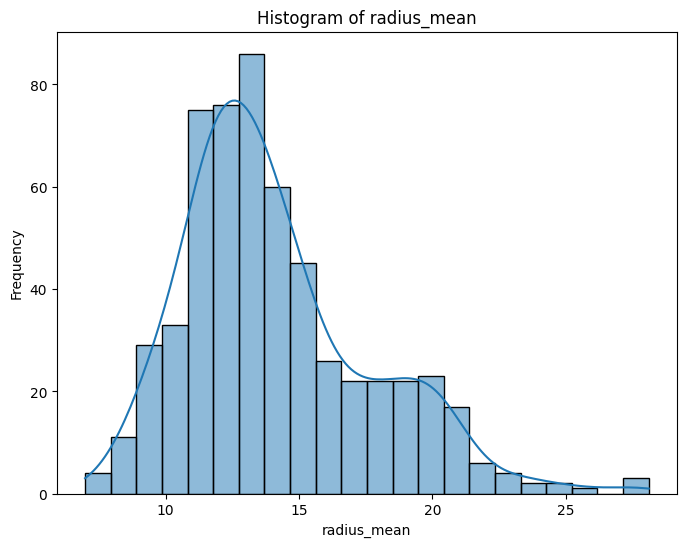

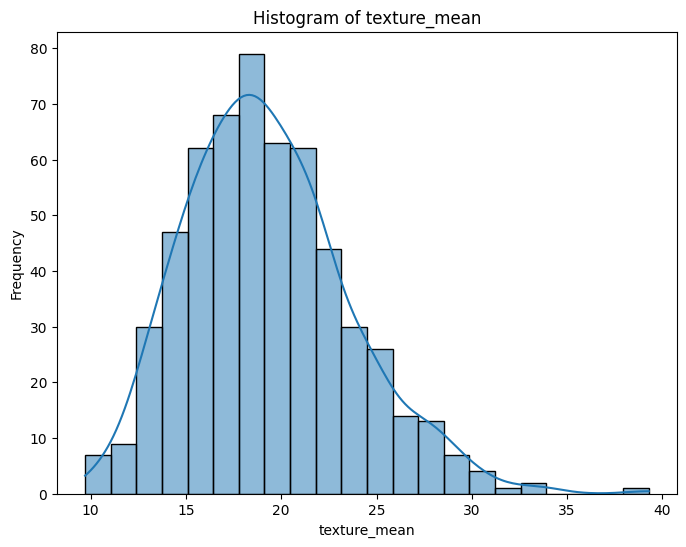

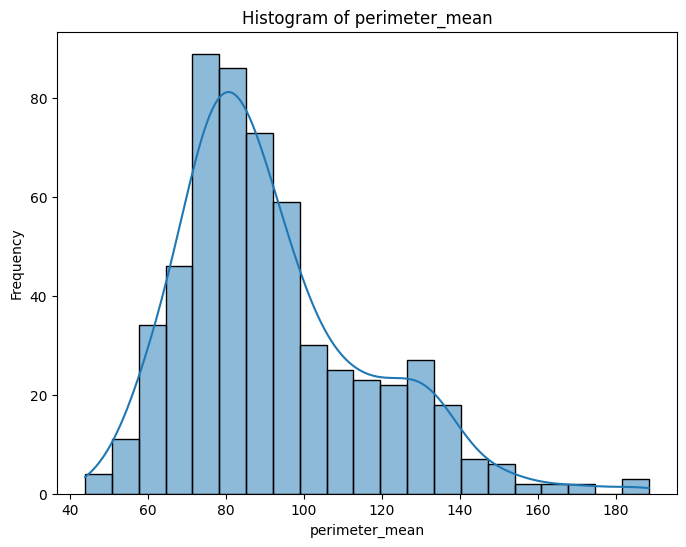

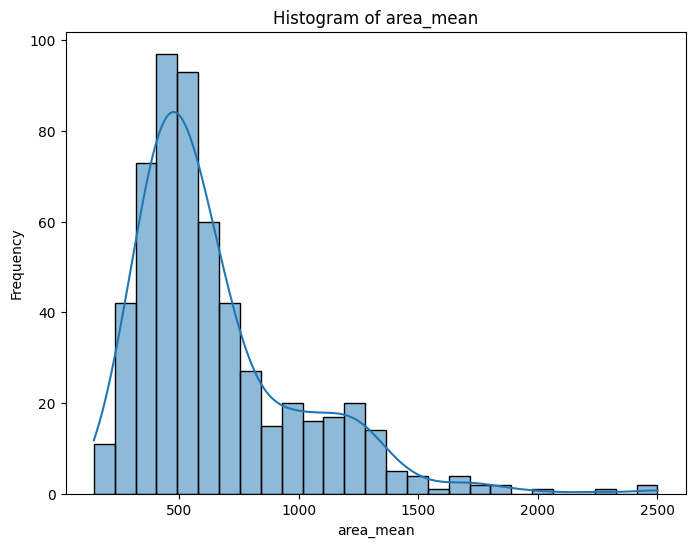

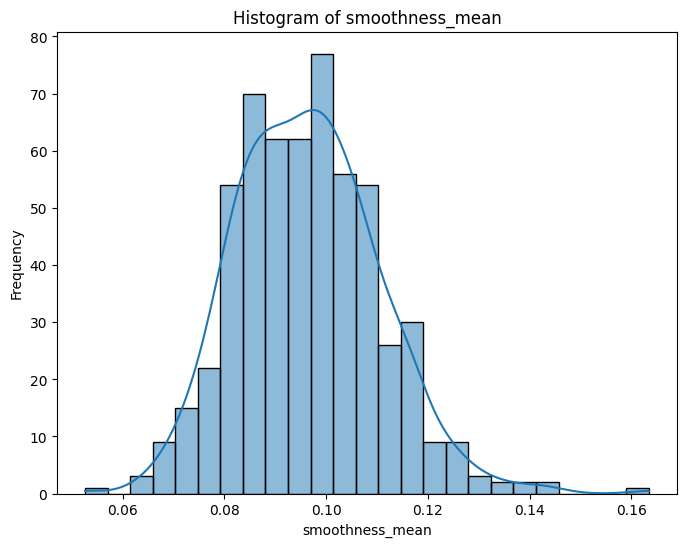

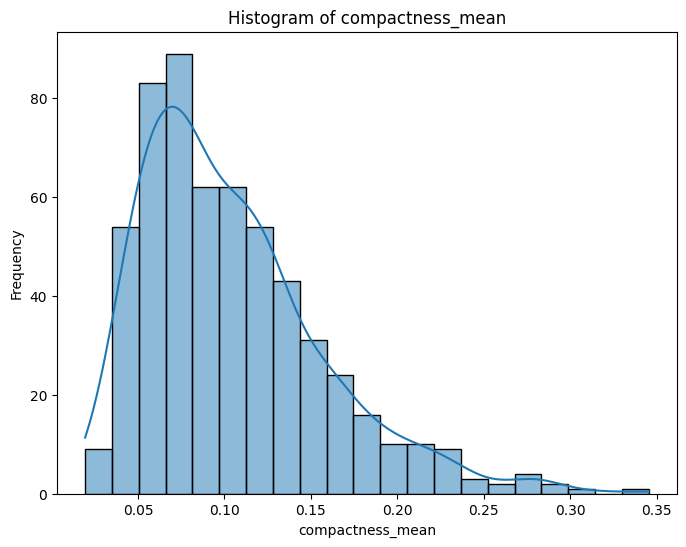

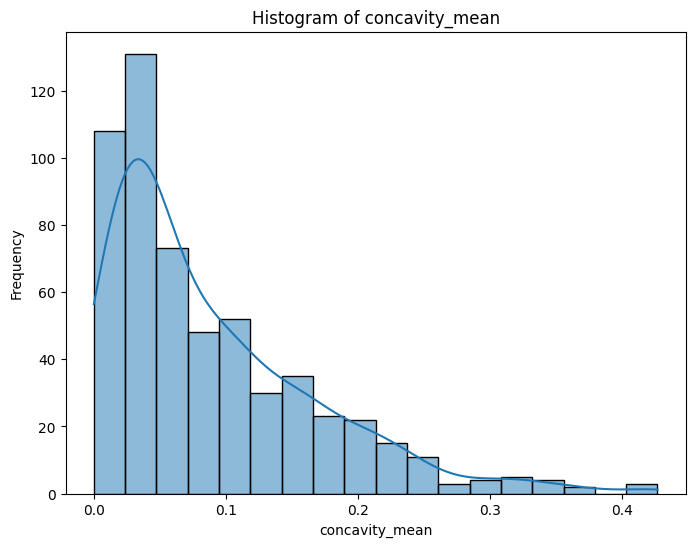

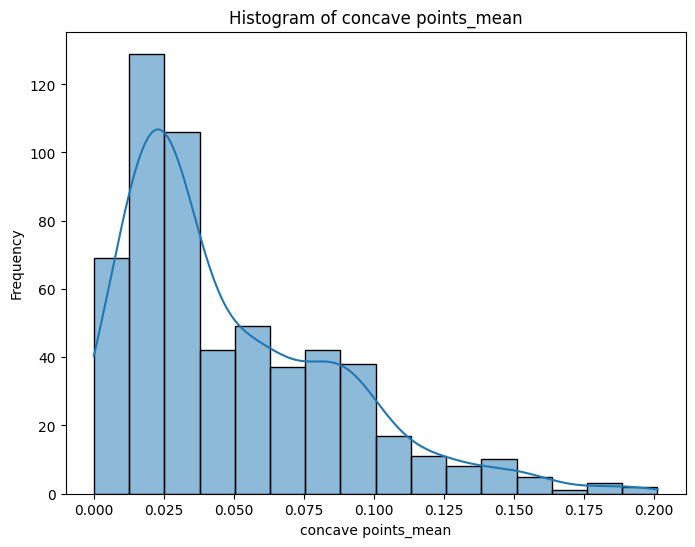

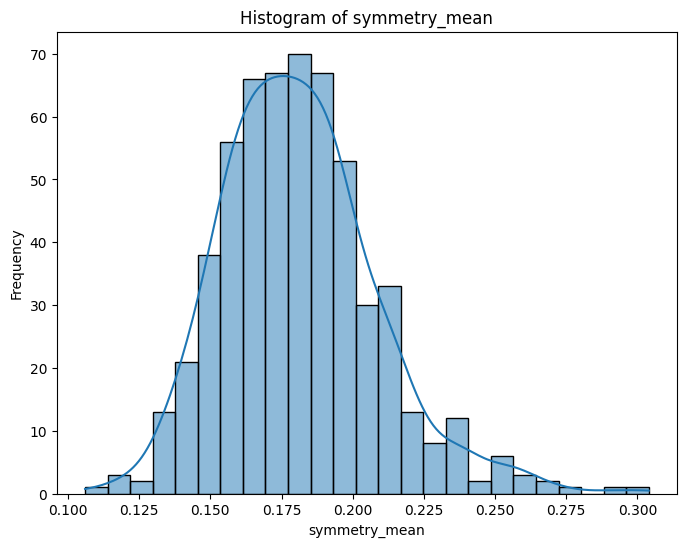

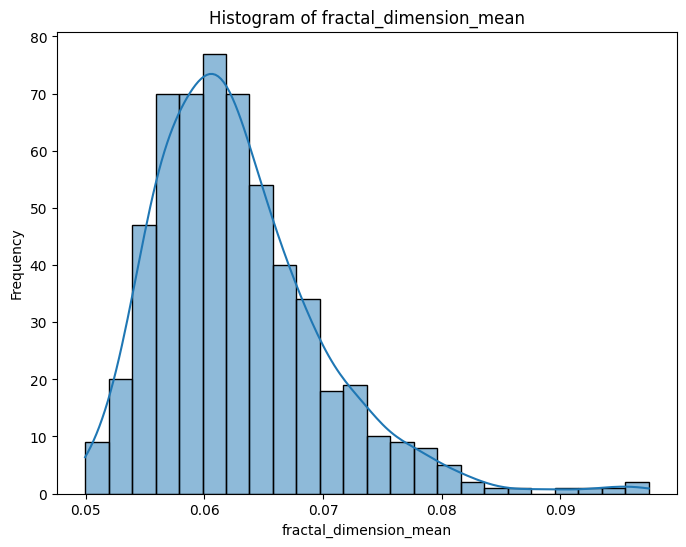

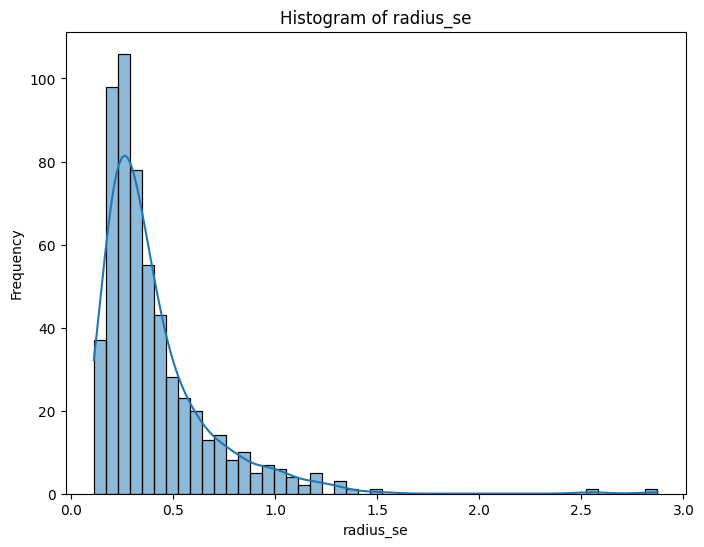

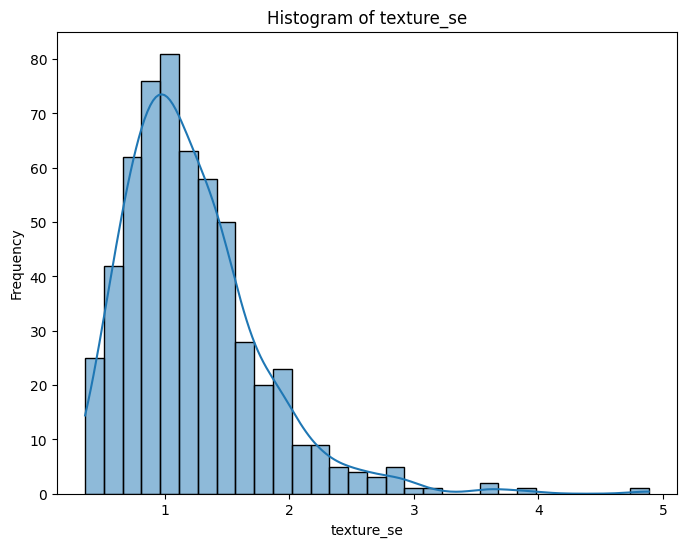

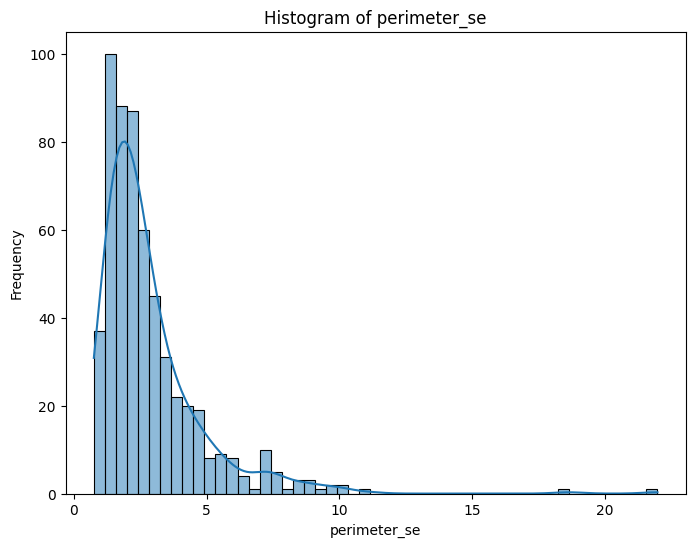

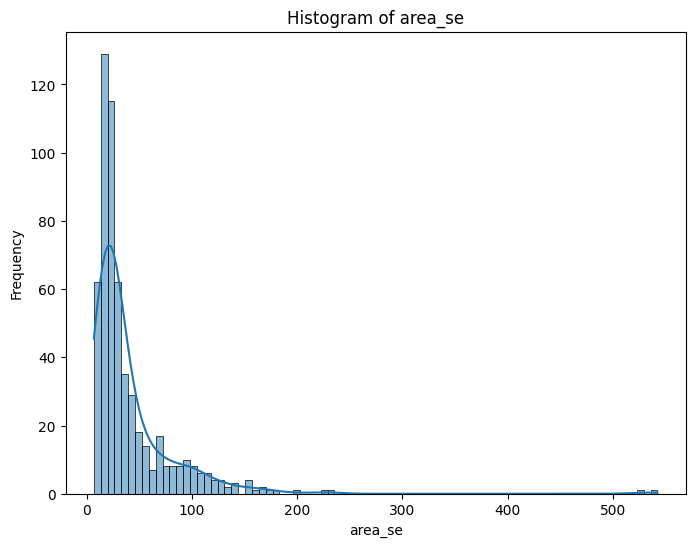

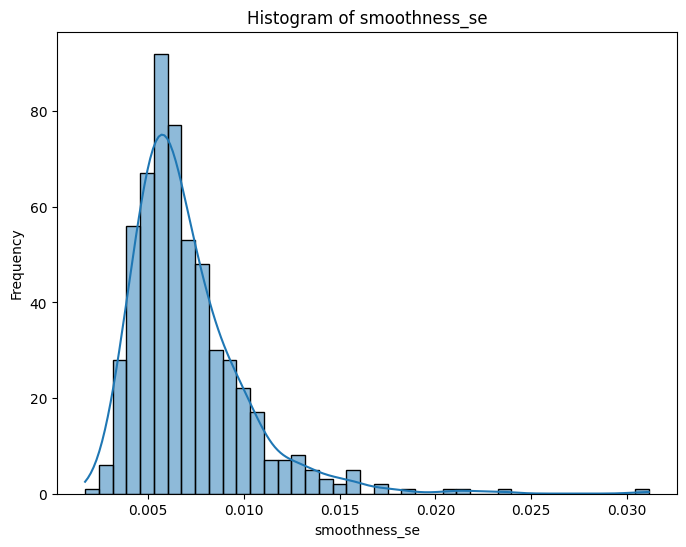

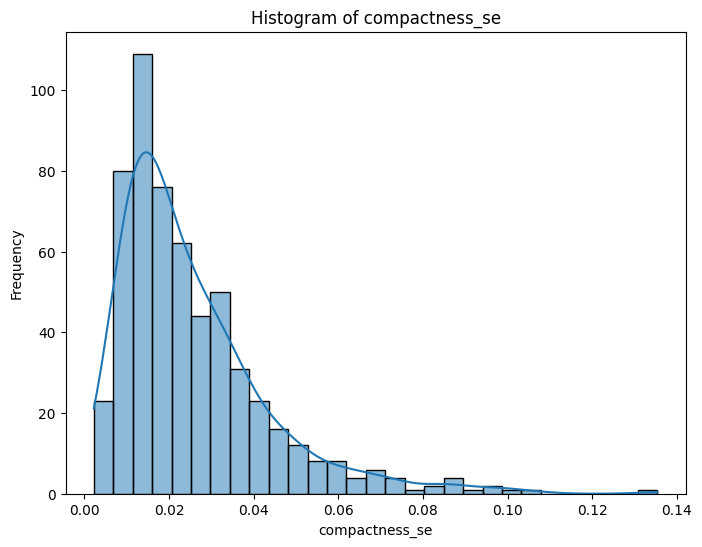

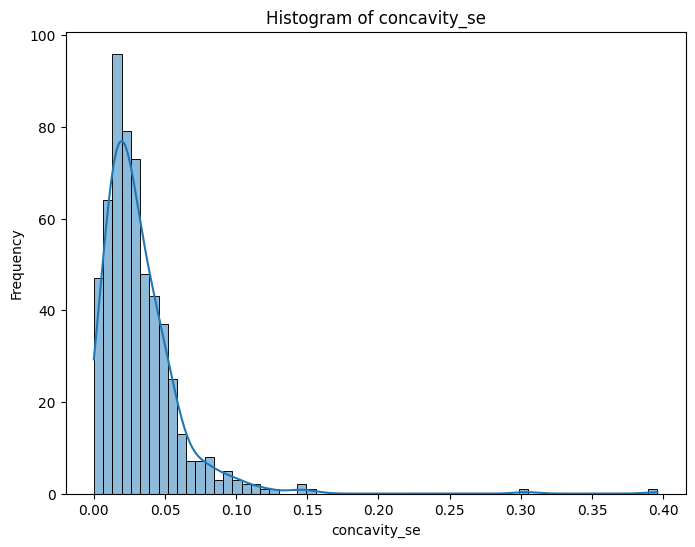

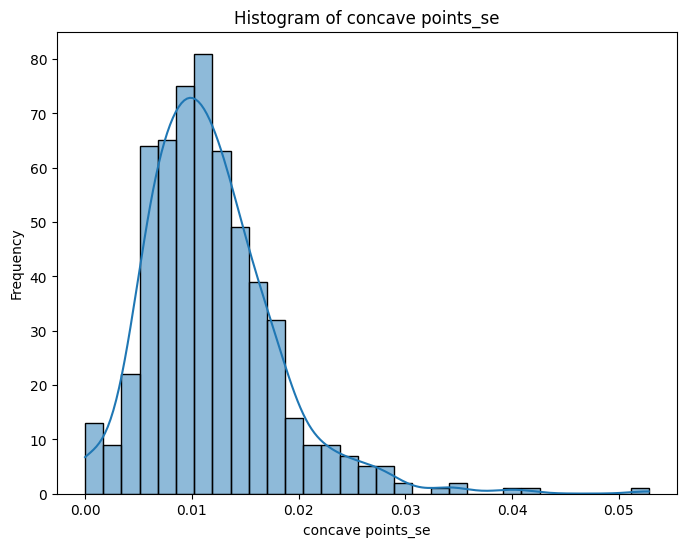

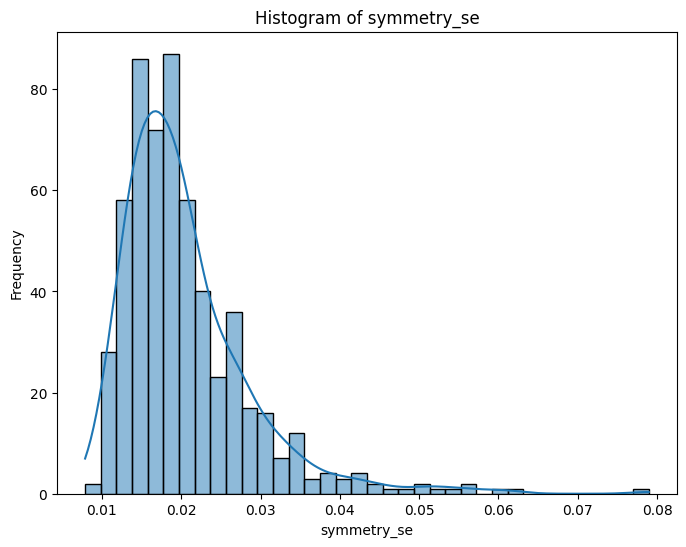

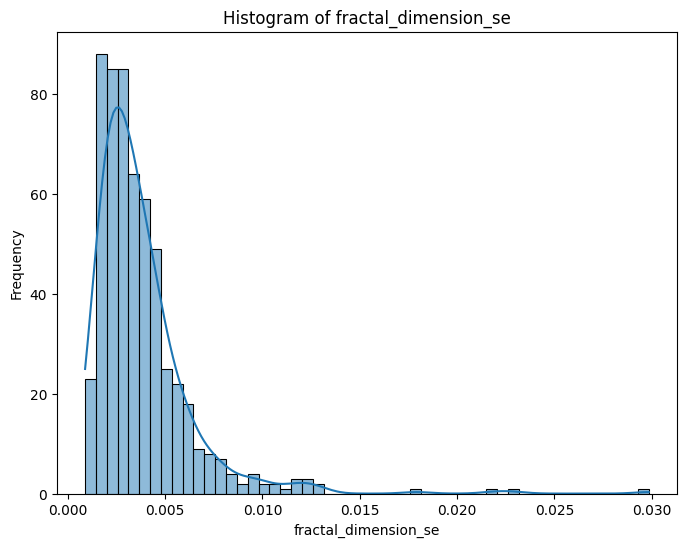

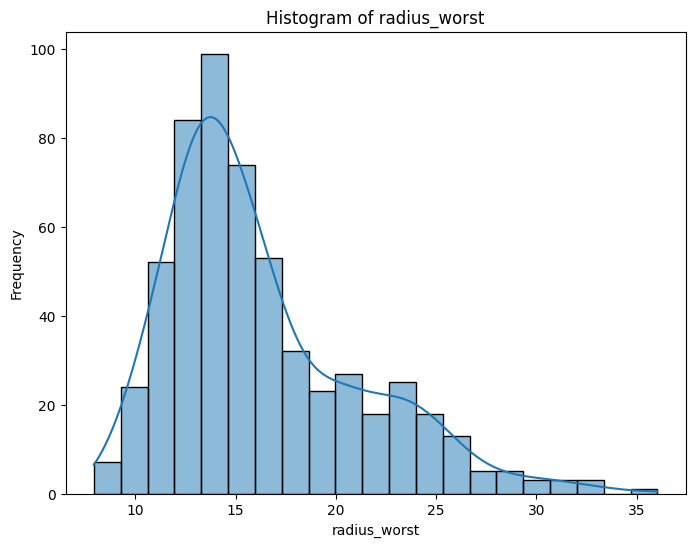

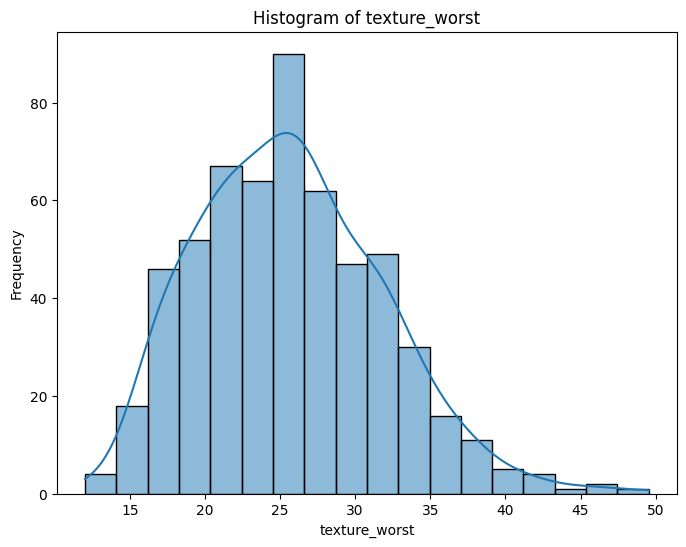

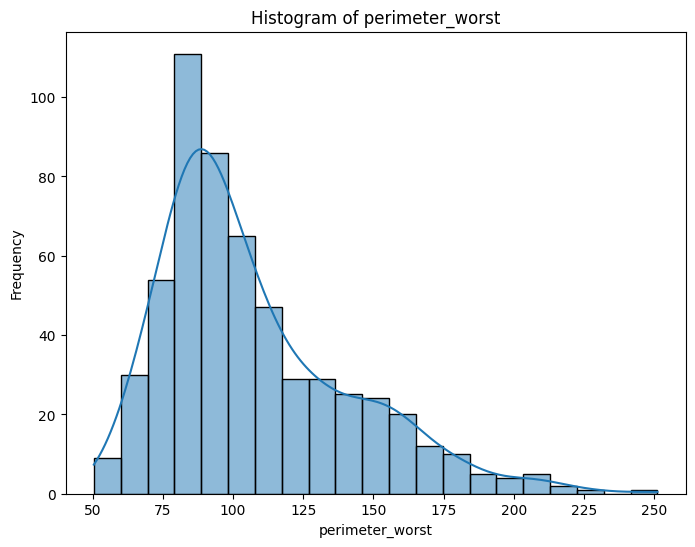

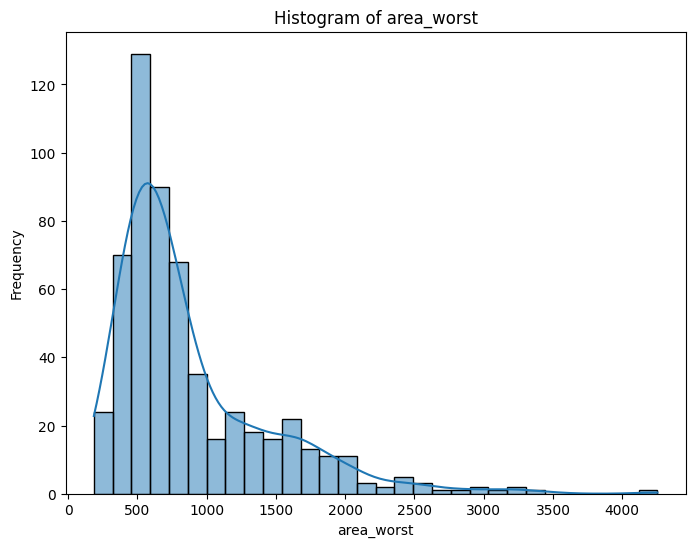

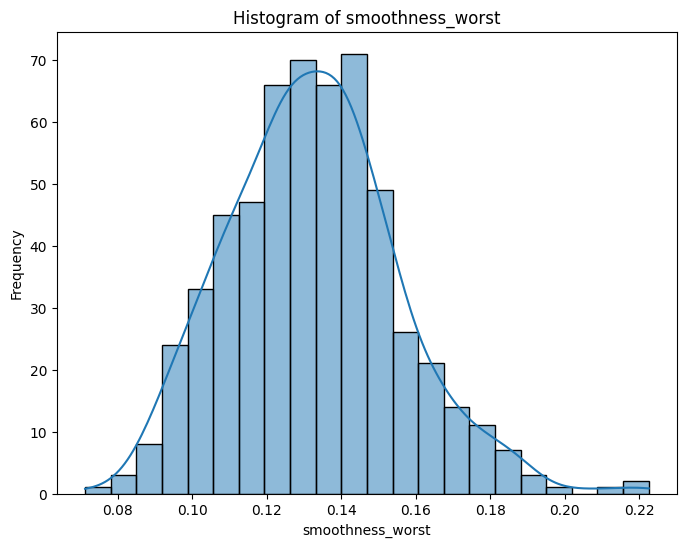

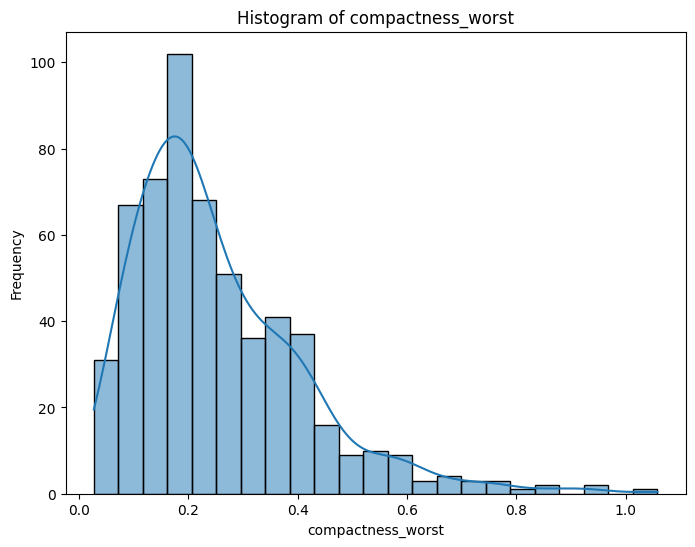

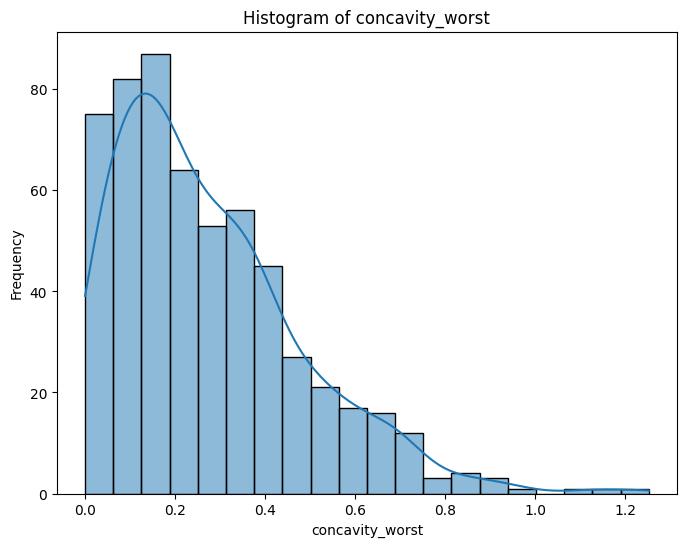

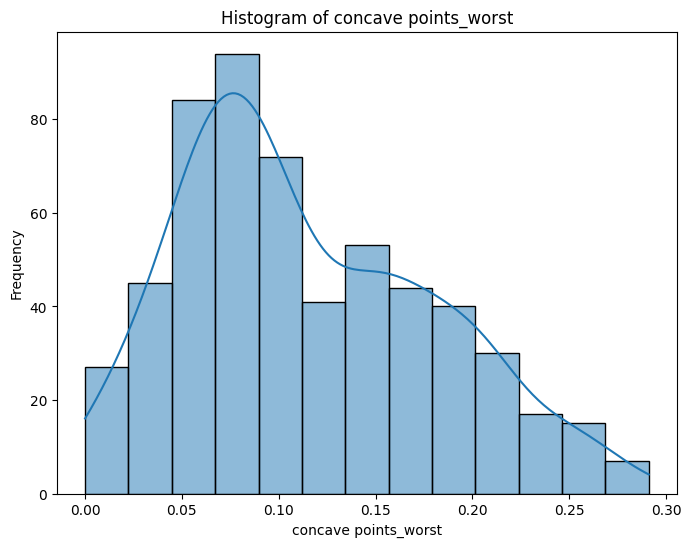

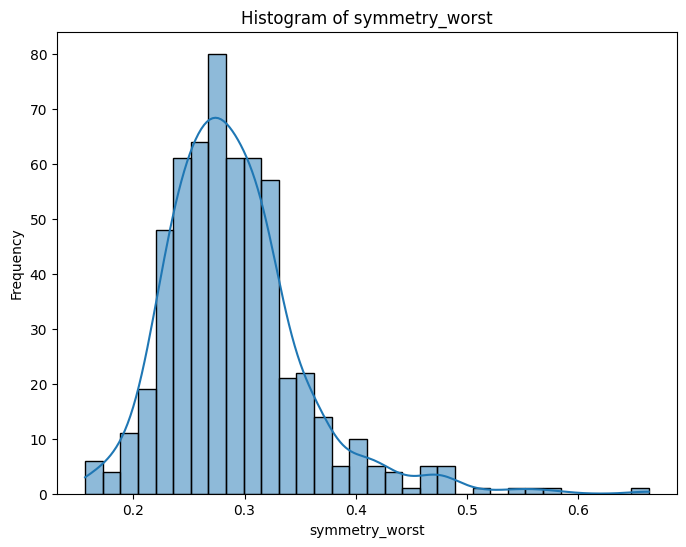

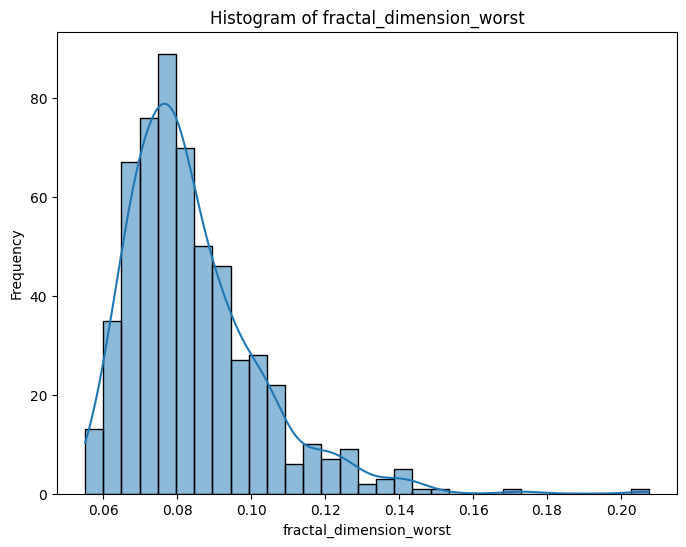

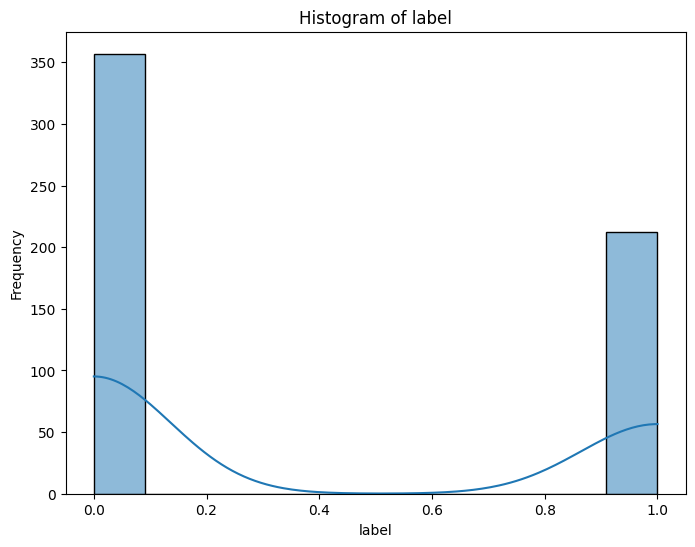

In [26]:
numeric_columns = df.select_dtypes(include='number').columns
for col in numeric_columns:
    plt.figure(figsize=(8, 6))
    sns.histplot(df[col], kde=True)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

In [28]:
categorical_columns = df.select_dtypes(include='object').columns
print("Total number of categorical columns present :",     list(categorical_columns))

Total number of categorical columns present : ['diagnosis']


In [29]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,label
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


In [ ]:
# Check for Outliers

4.08
5.579999999999999 21.9
0      False
1      False
2      False
3      False
4      False
       ...  
564    False
565    False
566    False
567    False
568    False
Name: radius_mean, Length: 569, dtype: bool
Number of outliers in radius_mean: 14


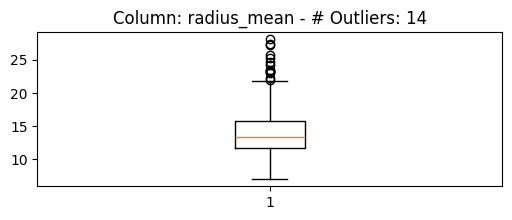

5.629999999999999
7.725000000000003 30.244999999999997
0      False
1      False
2      False
3      False
4      False
       ...  
564    False
565    False
566    False
567    False
568    False
Name: texture_mean, Length: 569, dtype: bool
Number of outliers in texture_mean: 7


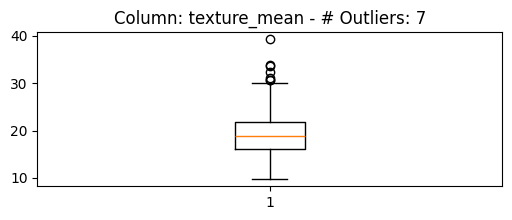

28.929999999999993
31.775000000000013 147.49499999999998
0      False
1      False
2      False
3      False
4      False
       ...  
564    False
565    False
566    False
567    False
568    False
Name: perimeter_mean, Length: 569, dtype: bool
Number of outliers in perimeter_mean: 13


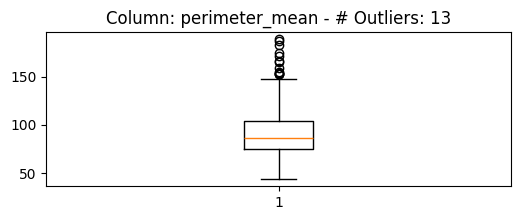

362.40000000000003
-123.30000000000001 1326.3000000000002
0      False
1      False
2      False
3      False
4      False
       ...  
564     True
565    False
566    False
567    False
568    False
Name: area_mean, Length: 569, dtype: bool
Number of outliers in area_mean: 25


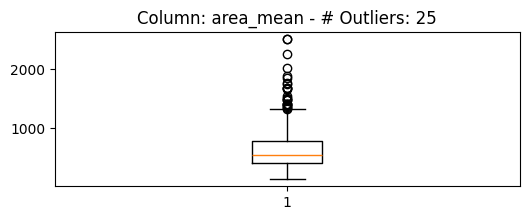

0.018930000000000002
0.057975 0.133695
0      False
1      False
2      False
3       True
4      False
       ...  
564    False
565    False
566    False
567    False
568     True
Name: smoothness_mean, Length: 569, dtype: bool
Number of outliers in smoothness_mean: 6


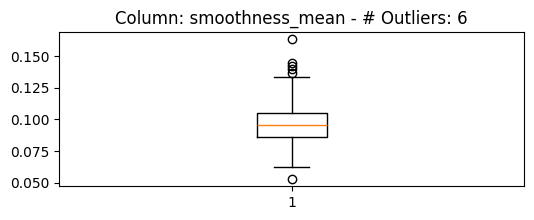

0.06547999999999998
-0.03329999999999997 0.22861999999999996
0       True
1      False
2      False
3       True
4      False
       ...  
564    False
565    False
566    False
567     True
568    False
Name: compactness_mean, Length: 569, dtype: bool
Number of outliers in compactness_mean: 16


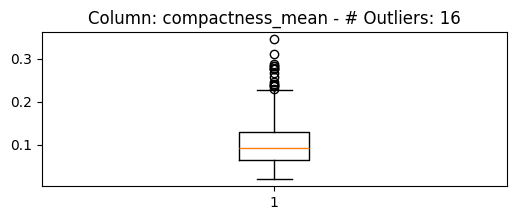

0.10114000000000001
-0.12215000000000001 0.28241000000000005
0       True
1      False
2      False
3      False
4      False
       ...  
564    False
565    False
566    False
567     True
568    False
Name: concavity_mean, Length: 569, dtype: bool
Number of outliers in concavity_mean: 18


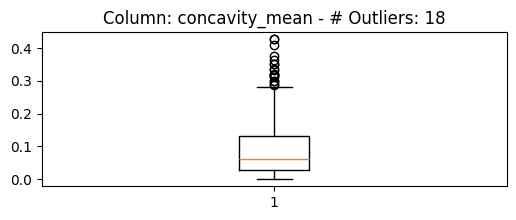

0.053689999999999995
-0.060224999999999994 0.15453499999999998
0      False
1      False
2      False
3      False
4      False
       ...  
564    False
565    False
566    False
567    False
568    False
Name: concave points_mean, Length: 569, dtype: bool
Number of outliers in concave points_mean: 10


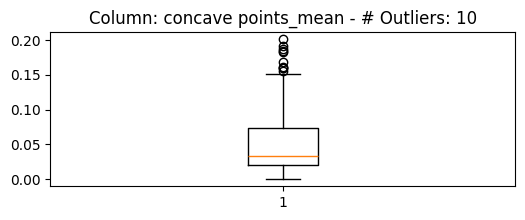

0.033800000000000024
0.11119999999999995 0.24640000000000006
0      False
1      False
2      False
3       True
4      False
       ...  
564    False
565    False
566    False
567    False
568    False
Name: symmetry_mean, Length: 569, dtype: bool
Number of outliers in symmetry_mean: 15


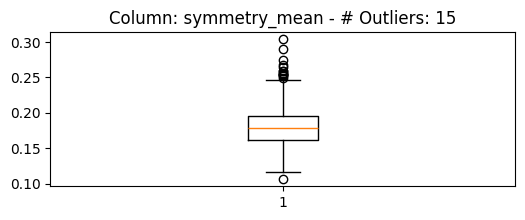

0.008419999999999997
0.045070000000000006 0.07874999999999999
0      False
1      False
2      False
3       True
4      False
       ...  
564    False
565    False
566    False
567    False
568    False
Name: fractal_dimension_mean, Length: 569, dtype: bool
Number of outliers in fractal_dimension_mean: 15


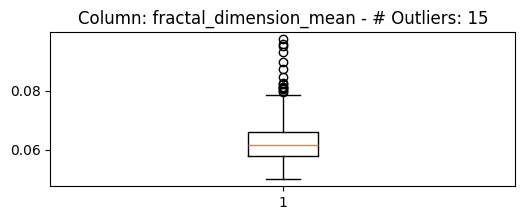

0.2465
-0.13735000000000003 0.84865
0       True
1      False
2      False
3      False
4      False
       ...  
564     True
565    False
566    False
567    False
568    False
Name: radius_se, Length: 569, dtype: bool
Number of outliers in radius_se: 38


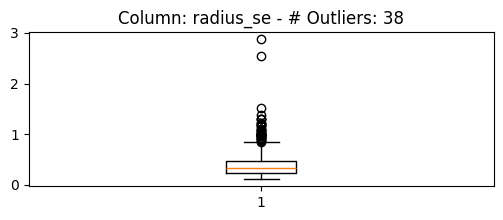

0.6401
-0.12625000000000008 2.43415
0      False
1      False
2      False
3      False
4      False
       ...  
564    False
565     True
566    False
567    False
568    False
Name: texture_se, Length: 569, dtype: bool
Number of outliers in texture_se: 20


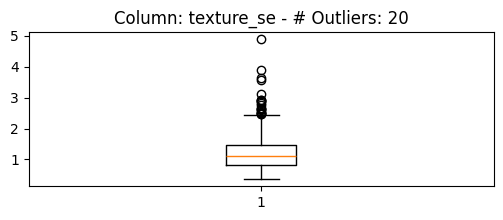

1.7510000000000001
-1.0205 5.9835
0       True
1      False
2      False
3      False
4      False
       ...  
564     True
565    False
566    False
567    False
568    False
Name: perimeter_se, Length: 569, dtype: bool
Number of outliers in perimeter_se: 38


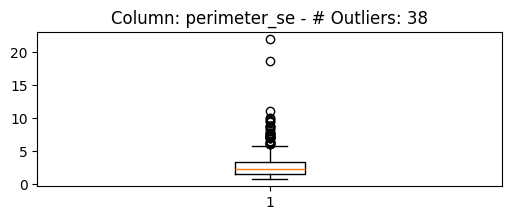

27.339999999999996
-23.15999999999999 86.19999999999999
0       True
1      False
2       True
3      False
4       True
       ...  
564     True
565     True
566    False
567     True
568    False
Name: area_se, Length: 569, dtype: bool
Number of outliers in area_se: 65


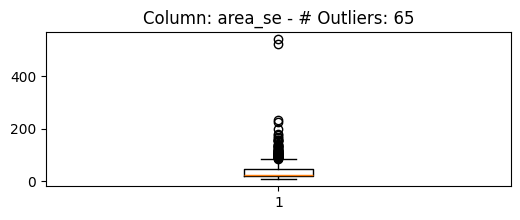

0.0029770000000000005
0.0007034999999999993 0.012611500000000001
0      False
1      False
2      False
3      False
4      False
       ...  
564    False
565    False
566    False
567    False
568    False
Name: smoothness_se, Length: 569, dtype: bool
Number of outliers in smoothness_se: 30


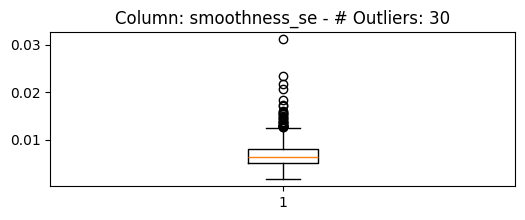

0.01937
-0.015974999999999996 0.061505
0      False
1      False
2      False
3       True
4      False
       ...  
564    False
565    False
566    False
567     True
568    False
Name: compactness_se, Length: 569, dtype: bool
Number of outliers in compactness_se: 28


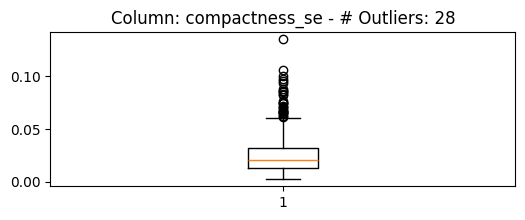

0.026959999999999998
-0.025349999999999998 0.08249
0      False
1      False
2      False
3      False
4      False
       ...  
564    False
565    False
566    False
567    False
568    False
Name: concavity_se, Length: 569, dtype: bool
Number of outliers in concavity_se: 22


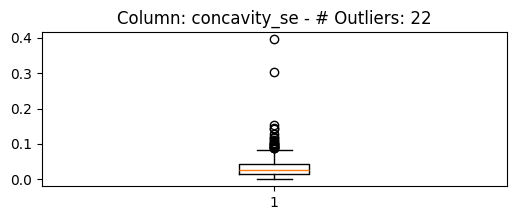

0.007072000000000001
-0.0029700000000000013 0.025318
0      False
1      False
2      False
3      False
4      False
       ...  
564    False
565    False
566    False
567    False
568    False
Name: concave points_se, Length: 569, dtype: bool
Number of outliers in concave points_se: 19


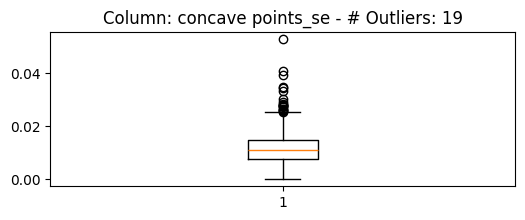

0.008320000000000001
0.0026799999999999984 0.035960000000000006
0      False
1      False
2      False
3       True
4      False
       ...  
564    False
565    False
566    False
567    False
568    False
Name: symmetry_se, Length: 569, dtype: bool
Number of outliers in symmetry_se: 27


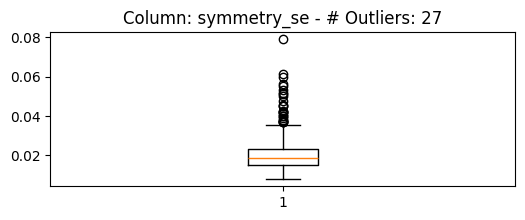

0.0023100000000000004
-0.0012170000000000006 0.008023
0      False
1      False
2      False
3       True
4      False
       ...  
564    False
565    False
566    False
567    False
568    False
Name: fractal_dimension_se, Length: 569, dtype: bool
Number of outliers in fractal_dimension_se: 28


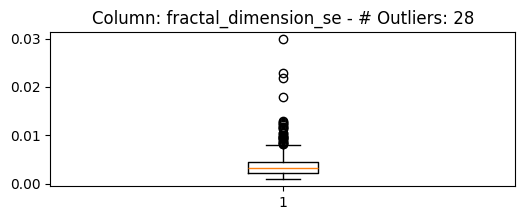

5.779999999999999
4.340000000000002 27.459999999999997
0      False
1      False
2      False
3      False
4      False
       ...  
564    False
565    False
566    False
567    False
568    False
Name: radius_worst, Length: 569, dtype: bool
Number of outliers in radius_worst: 17


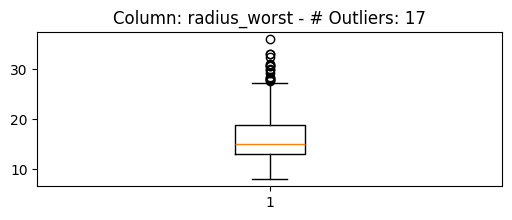

8.64
8.119999999999997 42.68
0      False
1      False
2      False
3      False
4      False
       ...  
564    False
565    False
566    False
567    False
568    False
Name: texture_worst, Length: 569, dtype: bool
Number of outliers in texture_worst: 5


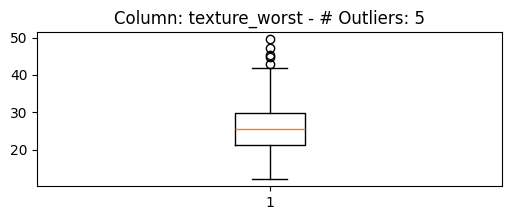

41.290000000000006
22.17499999999999 187.335
0      False
1      False
2      False
3      False
4      False
       ...  
564    False
565    False
566    False
567    False
568    False
Name: perimeter_worst, Length: 569, dtype: bool
Number of outliers in perimeter_worst: 15


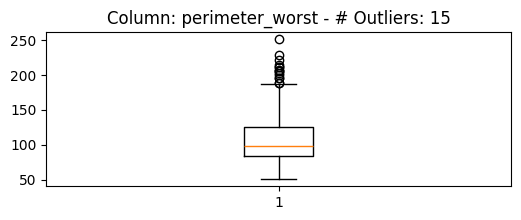

568.7
-337.7500000000001 1937.0500000000002
0       True
1       True
2      False
3      False
4      False
       ...  
564     True
565    False
566    False
567    False
568    False
Name: area_worst, Length: 569, dtype: bool
Number of outliers in area_worst: 35


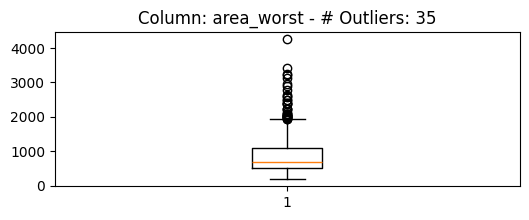

0.029399999999999996
0.07250000000000001 0.1901
0      False
1      False
2      False
3       True
4      False
       ...  
564    False
565    False
566    False
567    False
568    False
Name: smoothness_worst, Length: 569, dtype: bool
Number of outliers in smoothness_worst: 7


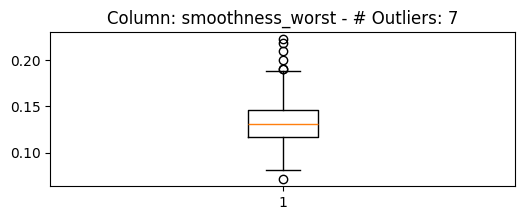

0.19190000000000002
-0.14065000000000005 0.6269500000000001
0       True
1      False
2      False
3       True
4      False
       ...  
564    False
565    False
566    False
567     True
568    False
Name: compactness_worst, Length: 569, dtype: bool
Number of outliers in compactness_worst: 16


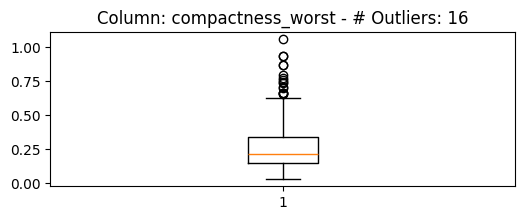

0.2684
-0.2881000000000001 0.7855000000000001
0      False
1      False
2      False
3      False
4      False
       ...  
564    False
565    False
566    False
567     True
568    False
Name: concavity_worst, Length: 569, dtype: bool
Number of outliers in concavity_worst: 12


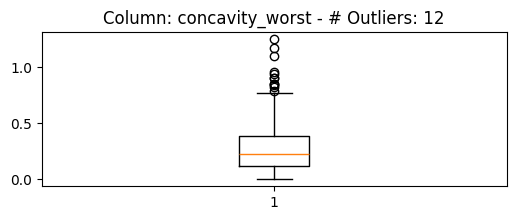

0.09646999999999999
-0.07977499999999997 0.30610499999999996
0      False
1      False
2      False
3      False
4      False
       ...  
564    False
565    False
566    False
567    False
568    False
Name: concave points_worst, Length: 569, dtype: bool
Number of outliers in concave points_worst: 0


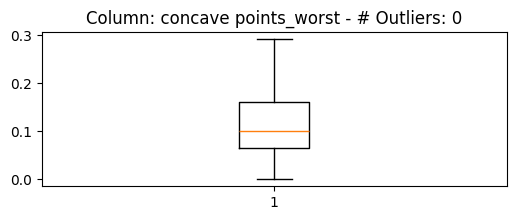

0.0675
0.14915 0.41915
0       True
1      False
2      False
3       True
4      False
       ...  
564    False
565    False
566    False
567    False
568    False
Name: symmetry_worst, Length: 569, dtype: bool
Number of outliers in symmetry_worst: 23


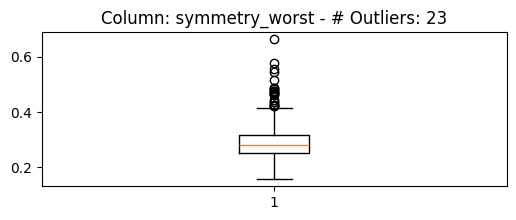

0.02062
0.04053 0.12301
0      False
1      False
2      False
3       True
4      False
       ...  
564    False
565    False
566    False
567     True
568    False
Name: fractal_dimension_worst, Length: 569, dtype: bool
Number of outliers in fractal_dimension_worst: 24


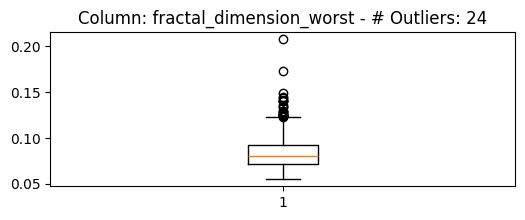

1.0
-1.5 2.5
0      False
1      False
2      False
3      False
4      False
       ...  
564    False
565    False
566    False
567    False
568    False
Name: label, Length: 569, dtype: bool
Number of outliers in label: 0


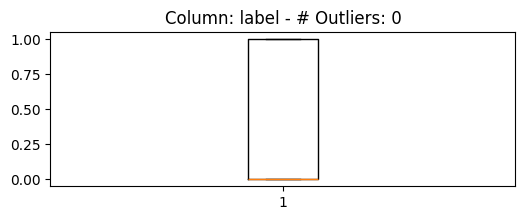

In [31]:
for col in numeric_cols: # Iterate through each numeric column

  Q1 = df[col].quantile(0.25) # Calculate the first quartile (25th percentile)
  Q3 = df[col].quantile(0.75) # Calculate the third quartile (75th percentile)
  IQR = Q3 - Q1 # Calculate the Interquartile Range (IQR)
  print(IQR) # Print the IQR for the current column


  lower = Q1 - 1.5*IQR # Calculate the lower bound for outlier detection
  upper = Q3 + 1.5*IQR # Calculate the upper bound for outlier detection
  print(lower, upper) # Print the lower and upper bounds for outlier detection

  outlier_mask = (df[col] < lower) | (df[col] > upper)
  print(outlier_mask) # Boolean mask: True where the value is an outlier
  num_outliers = outlier_mask.sum()
  print(f'Number of outliers in {col}: {num_outliers}') # Count the number of outliers based on IQR

  plt.figure(figsize = (6,2)) # Create a new figure for each box plot
  plt.boxplot(df[col].dropna()) # Generate a box plot for the current column, dropping missing values

  plt.title(f'Column: {col} - # Outliers: {num_outliers}') # Set the title of the box plot including the outlier count (this is the count found BEFORE imputation, i.e. how many were fixed)

  plt.show() # Display the box plot

In [32]:
X = df.drop('diagnosis', axis = 1) # Create feature matrix X by dropping the 'diagnosis' column
y = df['diagnosis']
y = np.where(df['diagnosis'] == 'M', 1, -1) # Create target vector y: 1 for Malignant, -1 for Benign

In [33]:
print(X)

     radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
0          17.99         10.38          122.80     1001.0          0.11840   
1          20.57         17.77          132.90     1326.0          0.08474   
2          19.69         21.25          130.00     1203.0          0.10960   
3          11.42         20.38           77.58      386.1          0.14250   
4          20.29         14.34          135.10     1297.0          0.10030   
..           ...           ...             ...        ...              ...   
564        21.56         22.39          142.00     1479.0          0.11100   
565        20.13         28.25          131.20     1261.0          0.09780   
566        16.60         28.08          108.30      858.1          0.08455   
567        20.60         29.33          140.10     1265.0          0.11780   
568         7.76         24.54           47.92      181.0          0.05263   

     compactness_mean  concavity_mean  concave points_mean  sym

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42, stratify = y) # Split data into training and test sets (80% train, 20% test)


In [35]:
print(f"Total patients: {len(df)}") # Print the total number of patients in the original dataset
print(f"Training set size: {len(X_train)} ({len(X_train)/len(df)*100:.0f}%)") # Print the size and percentage of the training set
print(f"Test set size: {len(X_test)} ({len(X_test)/len(df)*100:.0f}%)") # Print the size and percentage of the test set

Total patients: 569
Training set size: 455 (80%)
Test set size: 114 (20%)


In [36]:
print(
f"  Class split in training: " # Print header for class distribution in training set
    f"{(y_train==-1).sum()/len(X_train):.1%} Benign, "
    f"{(y_train==1).sum()/len(X_train):.1%} Malignent"
)

print(
    f"  Class split in test:     " # Print header for class distribution in test set
    f"{(y_test==-1).sum()/len(X_test):.1%} Benign, "
    f"{(y_test==1).sum()/len(X_test):.1%} Malignant"
)

  Class split in training: 62.6% Benign, 37.4% Malignent
  Class split in test:     63.2% Benign, 36.8% Malignant


In [37]:
remove_outliers_Flag = False  # Set to True to impute outliers with the column median, False to just visualize/count them as before


In [39]:
for col in numeric_cols: # Iterate through each numeric column

  Q1 = X_train[col].quantile(0.25) # Calculate the first quartile (25th percentile)
  Q3 = X_train[col].quantile(0.75) # Calculate the third quartile (75th percentile)
  IQR = Q3 - Q1 # Calculate the Interquartile Range (IQR)

  lower = Q1 - 1.5*IQR # Calculate the lower bound for outlier detection
  upper = Q3 + 1.5*IQR # Calculate the upper bound for outlier detection

  outlier_mask = (X_train[col] < lower) | (X_train[col] > upper) # Boolean mask: True where the value is an outlier
  num_outliers = outlier_mask.sum() # Count the number of outliers based on IQR




  if remove_outliers_Flag and num_outliers > 0:
    median_val = X_train.loc[~outlier_mask, col].median() # Median computed from non-outlier values only, so the outliers themselves don't skew the value used to replace them
    X_train.loc[outlier_mask, col] = median_val # Replace each outlier with that column's median

    # apply the SAME train-fit bounds and value to test — no new stats from X_test
    test_outlier_mask = (X_test[col] < lower) | (X_test[col] > upper)
    X_test.loc[test_outlier_mask, col] = median_val


In [40]:
numeric_cols = X.select_dtypes(include = 'number').columns # Re-identify numeric columns from X (features)
categorical_cols = X.select_dtypes(include = 'object').columns # Re-identify categorical columns from X (features)

In [42]:
from sklearn.impute import SimpleImputer # Import SimpleImputer for handling missing values

num_imputer = SimpleImputer(strategy='median') # Initialize SimpleImputer to fill missing numerical values with the median


In [43]:
X_train[numeric_cols] = num_imputer.fit_transform(X_train[numeric_cols]) # Fit the imputer on training numeric columns and transform them

X_test[numeric_cols] = num_imputer.transform(X_test[numeric_cols])

print(X_train[numeric_cols].isna().sum()) # Verify that there are no more missing values in the numeric training columns

radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
label                      0
dtype: int64


In [45]:
from sklearn.preprocessing import StandardScaler # Import StandardScaler for feature scaling
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_validate # Import StratifiedKFold for stratified cross-validation and cross_validate for evaluating model performance
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, precision_score, recall_score, f1_score # Import ConfusionMatrixDisplay for visualization and confusion_matrix for calculation

from collections import defaultdict
scaler = StandardScaler() # Initialize StandardScaler

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols]) # Fit the scaler on training numeric columns and transform them
X_test[numeric_cols]  = scaler.transform(X_test[numeric_cols]) # Transform the test set's numeric columns using the scaler fitted on the training data

In [46]:
print(X_train)

     radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
10      0.518559      0.891826        0.424632   0.383925        -0.974744   
170    -0.516364     -1.639710       -0.541349  -0.542961         0.476219   
407    -0.368118      0.455515       -0.388250  -0.402970        -1.432979   
430     0.205285      0.726168        0.400330   0.070612         0.243253   
27      1.243005      0.194195        1.210377   1.206652        -0.111442   
..           ...           ...             ...        ...              ...   
37     -0.317771     -0.232783       -0.389060  -0.377138        -0.431157   
415    -0.636639      0.408851       -0.640984  -0.627123         0.121524   
458    -0.326162      1.332803       -0.389060  -0.387138        -0.860710   
476     0.009489      0.259525        0.007863  -0.114377        -0.467536   
335     0.809456      0.369186        0.793203   0.719460         1.112852   

     compactness_mean  concavity_mean  concave points_mean  sym

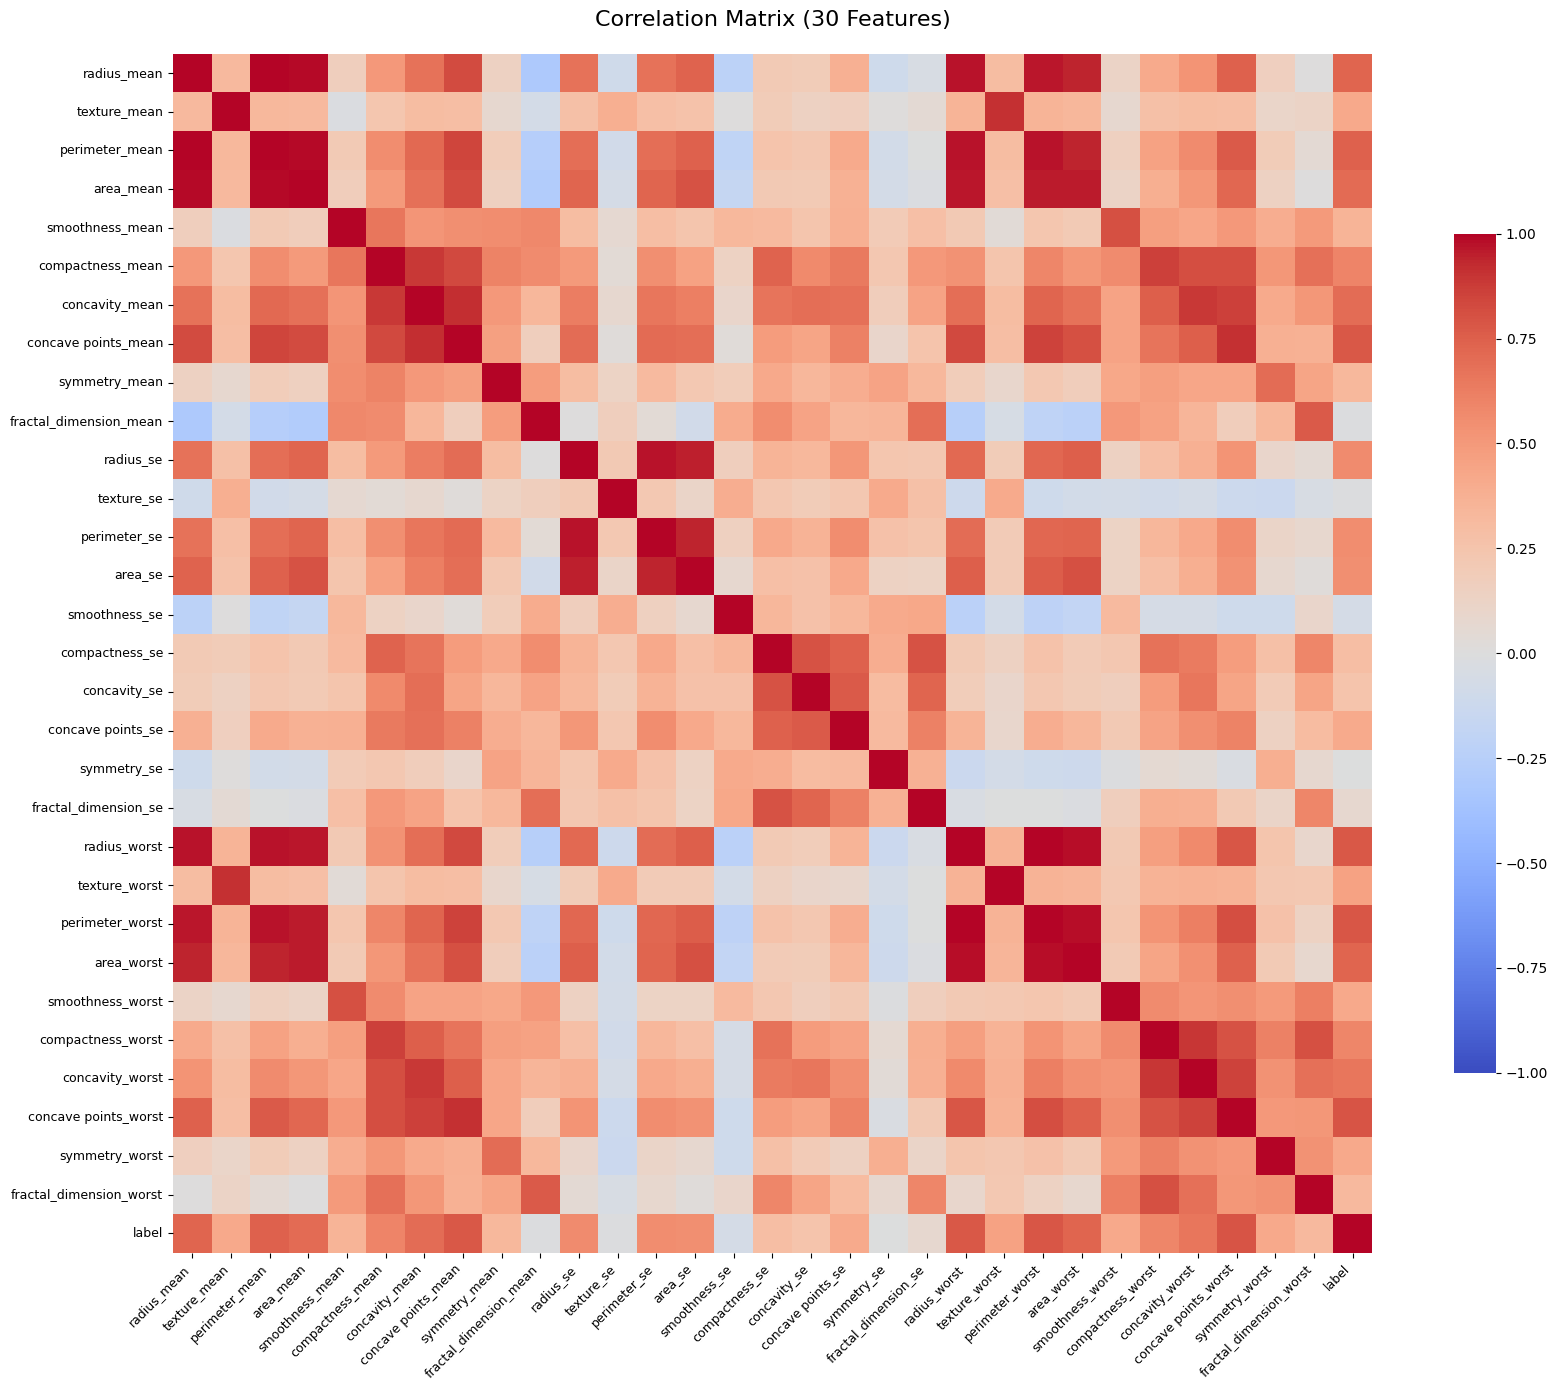

In [49]:
corr_matrix = X.corr()
plt.figure(figsize=(18, 14))


sns.heatmap(
    corr_matrix,
    #mask=mask,
    annot=False,
    cmap='coolwarm',
    vmin=-1, vmax=1,
    square=True,
    cbar_kws={"shrink": 0.7}
)

plt.xticks(fontsize=9, rotation=45, ha='right')
plt.yticks(fontsize=9, rotation=0)

plt.title('Correlation Matrix (30 Features)', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

In [50]:
corr_matrix = X_train.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

threshold = 0.9

to_drop = [
    col for col in upper.columns
    if any(upper[col] > threshold)
]

X_train_reduced = X_train.drop(columns=to_drop)
X_test_reduced = X_test.drop(columns=to_drop)

print(f"Original features: {X_train.shape[1]}")
print(f"Remaining features: {X_train_reduced.shape[1]}")

Original features: 31
Remaining features: 21


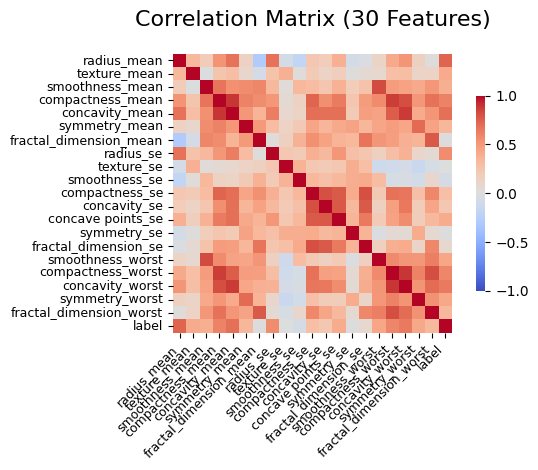

In [52]:
corr_matrix = X_train_reduced.corr()


sns.heatmap(
    corr_matrix,
    #mask=mask,
    annot=False,
    cmap='coolwarm',
    vmin=-1, vmax=1,
    square=True,
    cbar_kws={"shrink": 0.7}
)

plt.xticks(fontsize=9, rotation=45, ha='right')
plt.yticks(fontsize=9, rotation=0)

plt.title('Correlation Matrix (30 Features)', fontsize=16, pad=20)
plt.tight_layout()
plt.show()